# Analisis Bias Gender pada Representasi Pekerjaan Bahasa Indonesia Menggunakan SC-WEAT

Notebook ini menyusun analisis secara linear: persiapan → pembuatan data → pemahaman data → embedding → similarity → SC-WEAT → statistik → visualisasi → quality control → kesimpulan.

SC-WEAT mengukur asosiasi intrinsik dalam ruang embedding. Skor positif berarti representasi pekerjaan lebih dekat dengan atribut laki-laki, skor negatif lebih dekat dengan atribut perempuan, dan skor mendekati nol menunjukkan perbedaan asosiasi yang lemah pada konfigurasi pengujian. Hasil tidak membuktikan diskriminasi pada aplikasi nyata.

## 1. Import dan konfigurasi

Semua parameter utama diletakkan di awal agar mudah diperiksa dan direproduksi.

In [1]:
import json
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
plt.switch_backend("module://matplotlib_inline.backend_inline")
import seaborn as sns

from IPython.display import display

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
EMBEDDING_DIM = 300
N_PERMUTATIONS = 2000
ALPHA = 0.05
TOP_N = 10
OUTPUT_PREFIX = "demo_v1_"
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

configuration = pd.DataFrame({
    "parameter": ["RANDOM_SEED", "EMBEDDING_DIM", "N_PERMUTATIONS", "ALPHA", "TOP_N", "OUTPUT_PREFIX"],
    "value": [RANDOM_SEED, EMBEDDING_DIM, N_PERMUTATIONS, ALPHA, TOP_N, OUTPUT_PREFIX],
})
display(configuration)

,parameter,value
0,RANDOM_SEED,42
1,EMBEDDING_DIM,300
2,N_PERMUTATIONS,2000
3,ALPHA,0.05
4,TOP_N,10
5,OUTPUT_PREFIX,demo_v1_


## 2. Pembuatan data pekerjaan

Data pekerjaan dibentuk secara programatis dengan nama yang realistis dan tersebar pada sembilan kelompok klasifikasi-semu. Kelompok ini dibuat untuk kebutuhan analisis dan tidak diklaim sebagai salinan resmi KBJI.

In [2]:
occupation_groups = {
    "1": ("Manajer", ["direktur utama", "manajer operasional", "manajer keuangan", "manajer pemasaran", "kepala cabang", "supervisor produksi", "koordinator proyek", "manajer sumber daya manusia"]),
    "2": ("Profesional", ["dokter", "perawat", "guru", "dosen", "akuntan", "pengacara", "psikolog", "arsitek"]),
    "3": ("Teknisi dan asisten profesional", ["teknisi listrik", "teknisi jaringan", "analis sistem", "analis data", "pengembang perangkat lunak", "teknolog laboratorium", "radiografer", "asisten apoteker"]),
    "4": ("Tenaga tata usaha", ["sekretaris", "staf administrasi", "petugas arsip", "operator komputer", "resepsionis kantor", "staf keuangan", "petugas entri data", "sekretaris medis"]),
    "5": ("Tenaga usaha jasa dan penjualan", ["kasir", "pramusaji", "barista", "penata rambut", "agen perjalanan", "tenaga penjualan", "petugas layanan pelanggan", "pelayan toko"]),
    "6": ("Pekerja terampil pertanian dan perikanan", ["petani tanaman pangan", "pekebun hortikultura", "peternak sapi", "peternak unggas", "nelayan tangkap", "pembudidaya ikan", "penyadap karet", "pekerja kebun"]),
    "7": ("Pekerja pengolahan dan kerajinan", ["tukang kayu", "tukang batu", "penjahit", "pembuat roti", "pengrajin mebel", "tukang las", "pengrajin keramik", "perajin anyaman"]),
    "8": ("Operator dan perakit mesin", ["operator mesin", "operator forklift", "pengemudi truk", "pengemudi bus", "masinis", "operator pabrik", "perakit elektronik", "operator alat berat"]),
    "9": ("Pekerjaan elementer", ["petugas kebersihan", "pekerja rumah tangga", "buruh angkut", "penjaga malam", "pemulung", "pencuci kendaraan", "pekerja bongkar muat", "pembantu umum"]),
}

occupation_rows = []
for group_code, (group_name, names) in occupation_groups.items():
    for index, name in enumerate(names, start=1):
        occupation_rows.append({
            "occupation_id": f"{group_code}{index:02d}",
            "occupation_name": name,
            "major_group_code": group_code,
            "major_group_name": group_name,
            "token_count": len(name.split()),
        })

df_pekerjaan = pd.DataFrame(occupation_rows)
df_pekerjaan.to_csv(DATA_DIR / f"{OUTPUT_PREFIX}data_pekerjaan.csv", index=False)
display(df_pekerjaan.head(10))

,occupation_id,occupation_name,major_group_code,major_group_name,token_count
0,101,direktur utama,1,Manajer,2
1,102,manajer operasional,1,Manajer,2
2,103,manajer keuangan,1,Manajer,2
3,104,manajer pemasaran,1,Manajer,2
4,105,kepala cabang,1,Manajer,2
5,106,supervisor produksi,1,Manajer,2
6,107,koordinator proyek,1,Manajer,2
7,108,manajer sumber daya manusia,1,Manajer,4
8,201,dokter,2,Profesional,1
9,202,perawat,2,Profesional,1


## 3. Pemahaman data pekerjaan

Pemeriksaan awal memastikan struktur, kelengkapan, dan distribusi data terlihat sebelum representasi embedding dibuat.

In [3]:
display(df_pekerjaan.shape)
display(df_pekerjaan.dtypes.rename("dtype").to_frame())
display(df_pekerjaan.isna().sum().rename("missing_count").to_frame())
print("Jumlah duplikasi baris:", int(df_pekerjaan.duplicated().sum()))
display(df_pekerjaan["major_group_name"].value_counts().rename("occupation_count").to_frame())
display(df_pekerjaan.assign(name_type=np.where(df_pekerjaan["token_count"] == 1, "satu kata", "multi-kata"))["name_type"].value_counts().rename("occupation_count").to_frame())
display(df_pekerjaan.groupby("major_group_name", sort=False).head(2))

(72, 5)

,dtype
occupation_id,object
occupation_name,object
major_group_code,object
major_group_name,object
token_count,int64


,missing_count
occupation_id,0
occupation_name,0
major_group_code,0
major_group_name,0
token_count,0


Jumlah duplikasi baris: 0


,occupation_count
major_group_name,
Manajer,8
Profesional,8
Teknisi dan asisten profesional,8
Tenaga tata usaha,8
Tenaga usaha jasa dan penjualan,8
Pekerja terampil pertanian dan perikanan,8
Pekerja pengolahan dan kerajinan,8
Operator dan perakit mesin,8
Pekerjaan elementer,8


,occupation_count
name_type,
multi-kata,56
satu kata,16


,occupation_id,occupation_name,major_group_code,major_group_name,token_count
0,101,direktur utama,1,Manajer,2
1,102,manajer operasional,1,Manajer,2
8,201,dokter,2,Profesional,1
9,202,perawat,2,Profesional,1
16,301,teknisi listrik,3,Teknisi dan asisten profesional,2
17,302,teknisi jaringan,3,Teknisi dan asisten profesional,2
24,401,sekretaris,4,Tenaga tata usaha,1
25,402,staf administrasi,4,Tenaga tata usaha,2
32,501,kasir,5,Tenaga usaha jasa dan penjualan,1
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,1


### Visualisasi jumlah pekerjaan dan token

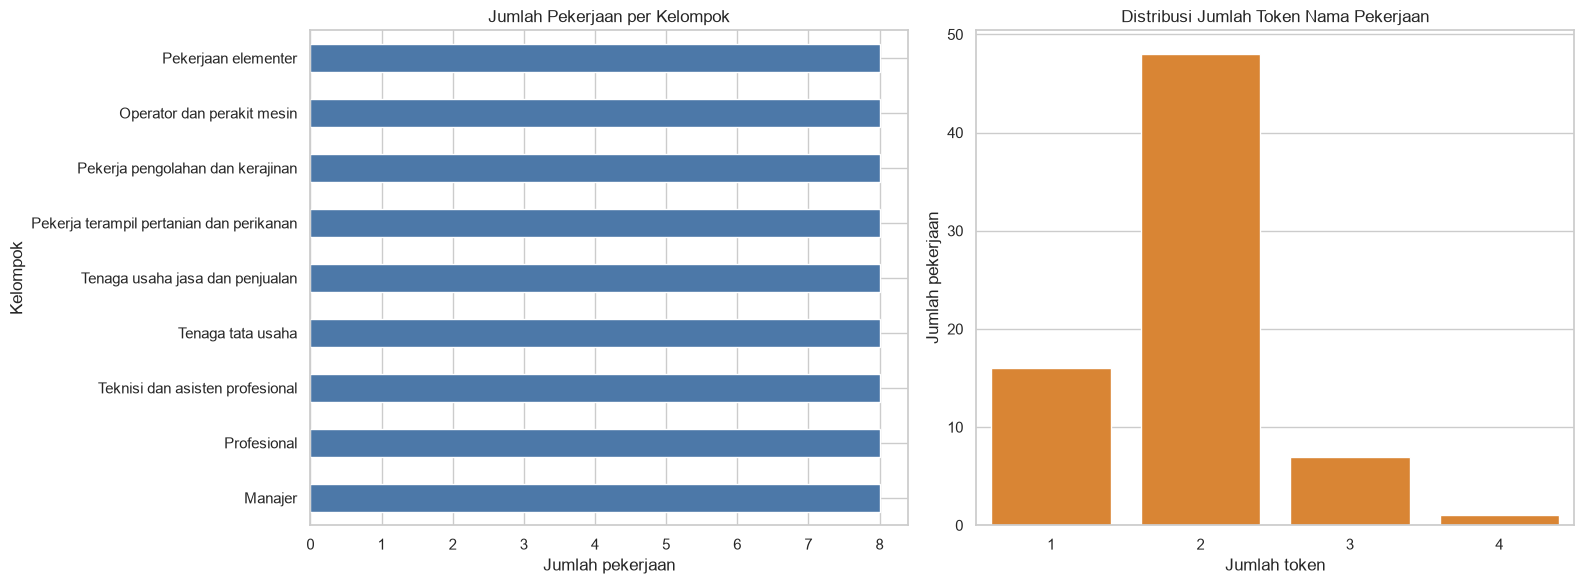

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_pekerjaan["major_group_name"].value_counts().sort_values().plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set(title="Jumlah Pekerjaan per Kelompok", xlabel="Jumlah pekerjaan", ylabel="Kelompok")
sns.countplot(data=df_pekerjaan, x="token_count", ax=axes[1], color="#F58518")
axes[1].set(title="Distribusi Jumlah Token Nama Pekerjaan", xlabel="Jumlah token", ylabel="Jumlah pekerjaan")
fig.tight_layout()
display(fig)
plt.close(fig)

## 4. Pembuatan istilah gender

Istilah berikut disusun berpasangan dan dikelompokkan berdasarkan konteks leksikal. Perbedaan kategori dapat membawa konteks semantik tambahan sehingga hasil perlu dibaca hati-hati.

In [5]:
gender_pairs_input = [
    ("G01", "laki-laki", "perempuan", "identitas umum"),
    ("G02", "pria", "wanita", "identitas umum"),
    ("G03", "ayah", "ibu", "kekerabatan"),
    ("G04", "suami", "istri", "perkawinan"),
    ("G05", "putra", "putri", "kekerabatan"),
    ("G06", "pemuda", "pemudi", "usia atau generasi"),
    ("G07", "cowok", "cewek", "informal"),
    ("G08", "jejaka", "gadis", "usia atau generasi"),
]

gender_rows = []
for pair_id, male, female, category in gender_pairs_input:
    gender_rows.extend([
        {"term_id": f"{pair_id}_M", "term": male, "gender_group": "laki-laki", "lexical_category": category, "pair_id": pair_id},
        {"term_id": f"{pair_id}_F", "term": female, "gender_group": "perempuan", "lexical_category": category, "pair_id": pair_id},
    ])

df_istilah_gender = pd.DataFrame(gender_rows)
df_istilah_gender.to_csv(DATA_DIR / f"{OUTPUT_PREFIX}istilah_gender.csv", index=False)
display(df_istilah_gender)
display(df_istilah_gender["gender_group"].value_counts().rename("term_count").to_frame())
display(df_istilah_gender["lexical_category"].value_counts().rename("term_count").to_frame())

,term_id,term,gender_group,lexical_category,pair_id
0,G01_M,laki-laki,laki-laki,identitas umum,G01
1,G01_F,perempuan,perempuan,identitas umum,G01
2,G02_M,pria,laki-laki,identitas umum,G02
3,G02_F,wanita,perempuan,identitas umum,G02
4,G03_M,ayah,laki-laki,kekerabatan,G03
5,G03_F,ibu,perempuan,kekerabatan,G03
6,G04_M,suami,laki-laki,perkawinan,G04
7,G04_F,istri,perempuan,perkawinan,G04
8,G05_M,putra,laki-laki,kekerabatan,G05
9,G05_F,putri,perempuan,kekerabatan,G05


,term_count
gender_group,
laki-laki,8
perempuan,8


,term_count
lexical_category,
identitas umum,4
kekerabatan,4
usia atau generasi,4
perkawinan,2
informal,2


In [32]:
pair_completeness = df_istilah_gender.groupby("pair_id")["gender_group"].nunique().rename("gender_group_count").to_frame()
duplicate_terms = df_istilah_gender[df_istilah_gender["term"].duplicated(keep=False)]
print("Pasangan tidak lengkap:")
display(pair_completeness[pair_completeness["gender_group_count"] != 2])
print("Duplikasi istilah:")
display(duplicate_terms)

Pasangan tidak lengkap:


,gender_group_count
pair_id,


Duplikasi istilah:


,term_id,term,gender_group,lexical_category,pair_id


## 5. Pembentukan representasi embedding berdimensi 300

Representasi dibangun dari satu ruang vektor. Arah laten gender, pusat kelompok pekerjaan, variasi token, dan sinyal gender pekerjaan digunakan untuk menghasilkan campuran asosiasi positif, negatif, dan mendekati nol. Nama pekerjaan multi-kata direpresentasikan dari rata-rata vektor token penyusunnya.

In [7]:
def get_phrase_vector(text, token_vectors):
    tokens = str(text).lower().split()
    return np.mean([token_vectors[token] for token in tokens], axis=0)


gender_axis = rng.normal(size=EMBEDDING_DIM)
gender_axis = gender_axis / np.linalg.norm(gender_axis)
male_center = 0.75 * gender_axis + rng.normal(0, 0.08, EMBEDDING_DIM)
female_center = -0.75 * gender_axis + rng.normal(0, 0.08, EMBEDDING_DIM)
male_center = male_center / np.linalg.norm(male_center)
female_center = female_center / np.linalg.norm(female_center)

token_vectors = {}
for term, group in zip(df_istilah_gender["term"], df_istilah_gender["gender_group"]):
    center = male_center if group == "laki-laki" else female_center
    token_vectors[term] = center + rng.normal(0, 0.12, EMBEDDING_DIM)

group_centers = {group_name: rng.normal(0, 0.35, EMBEDDING_DIM) for group_name, _ in occupation_groups.values()}
group_centers = {name: vector / np.linalg.norm(vector) for name, vector in group_centers.items()}
gender_signal = np.linspace(-0.65, 0.65, len(df_pekerjaan))
rng.shuffle(gender_signal)

for row, signal in zip(df_pekerjaan.itertuples(index=False), gender_signal):
    for token in row.occupation_name.split():
        if token not in token_vectors:
            token_vectors[token] = group_centers[row.major_group_name] + signal * 0.35 * gender_axis + rng.normal(0, 0.16, EMBEDDING_DIM)

occupation_vectors = np.vstack([get_phrase_vector(name, token_vectors) for name in df_pekerjaan["occupation_name"]])
occupation_vectors = occupation_vectors / np.linalg.norm(occupation_vectors, axis=1, keepdims=True)
term_vectors = np.vstack([token_vectors[term] for term in df_istilah_gender["term"]])
term_vectors = term_vectors / np.linalg.norm(term_vectors, axis=1, keepdims=True)

print("Jumlah token unik:", len(token_vectors))
print("Dimensi embedding:", EMBEDDING_DIM)
display(pd.DataFrame(occupation_vectors[:5, :5], index=df_pekerjaan["occupation_name"].head(5), columns=[f"dim_{i}" for i in range(1, 6)]).round(4))
display(pd.DataFrame({"occupation_name": df_pekerjaan["occupation_name"].head(5), "norm": np.linalg.norm(occupation_vectors[:5], axis=1)}).round(4))
print("Shape matriks embedding pekerjaan:", occupation_vectors.shape)
print("NaN:", bool(np.isnan(occupation_vectors).any()), "Infinity:", bool(np.isinf(occupation_vectors).any()))

Jumlah token unik: 130
Dimensi embedding: 300


,dim_1,dim_2,dim_3,dim_4,dim_5
occupation_name,,,,,
direktur utama,-0.0328,0.0110,0.0439,-0.0083,0.0017
manajer operasional,0.0040,0.0311,-0.0336,0.0232,-0.0460
manajer keuangan,0.0043,0.0753,0.0060,0.0411,0.0758
manajer pemasaran,-0.0583,0.0522,0.0093,0.0535,-0.1064
kepala cabang,-0.0714,0.0390,0.0936,0.0661,-0.0105


,occupation_name,norm
0,direktur utama,1.0
1,manajer operasional,1.0
2,manajer keuangan,1.0
3,manajer pemasaran,1.0
4,kepala cabang,1.0


Shape matriks embedding pekerjaan: (72, 300)
NaN: False Infinity: False


## 6. Visualisasi ruang embedding dengan PCA

PCA digunakan untuk membaca geometri embedding dalam dua dimensi. PCA bukan ukuran utama bias.

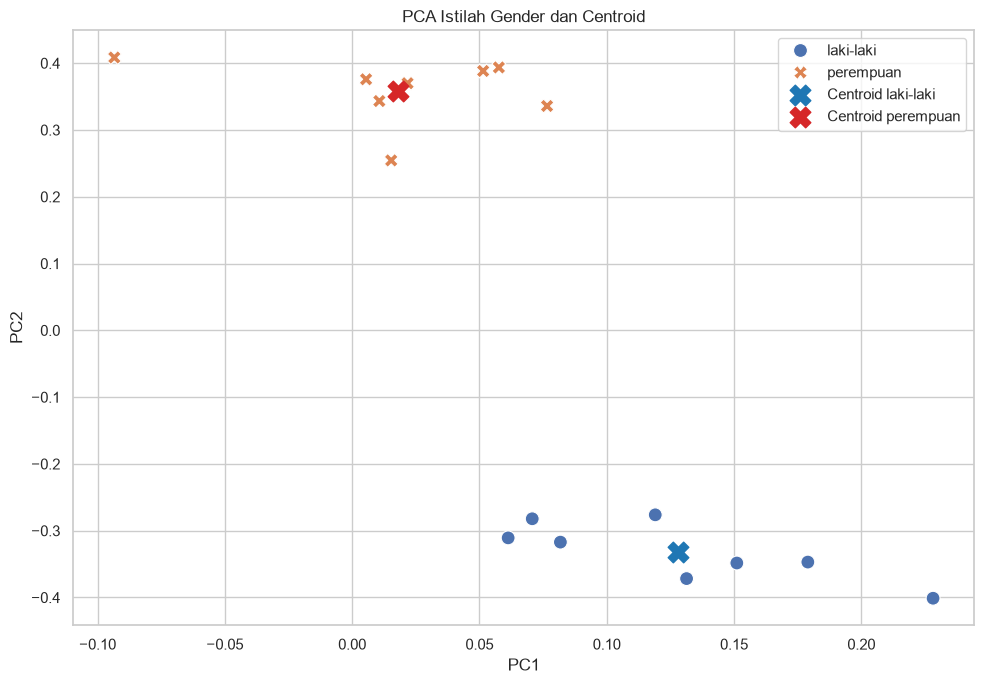

In [8]:
all_visual_vectors = np.vstack([term_vectors, occupation_vectors])
pca_coordinates = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(all_visual_vectors)
term_coordinates = pd.DataFrame(pca_coordinates[:len(df_istilah_gender)], columns=["PC1", "PC2"])
term_coordinates["term"] = df_istilah_gender["term"].values
term_coordinates["gender_group"] = df_istilah_gender["gender_group"].values
occupation_coordinates = pd.DataFrame(pca_coordinates[len(df_istilah_gender):], columns=["PC1", "PC2"])
occupation_coordinates = pd.concat([df_pekerjaan.reset_index(drop=True), occupation_coordinates], axis=1)

male_centroid = term_coordinates[term_coordinates["gender_group"] == "laki-laki"][["PC1", "PC2"]].mean()
female_centroid = term_coordinates[term_coordinates["gender_group"] == "perempuan"][["PC1", "PC2"]].mean()
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=term_coordinates, x="PC1", y="PC2", hue="gender_group", style="gender_group", s=100, ax=ax)
ax.scatter(*male_centroid, marker="X", s=220, color="#1f77b4", label="Centroid laki-laki")
ax.scatter(*female_centroid, marker="X", s=220, color="#d62728", label="Centroid perempuan")
ax.set(title="PCA Istilah Gender dan Centroid", xlabel="PC1", ylabel="PC2")
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

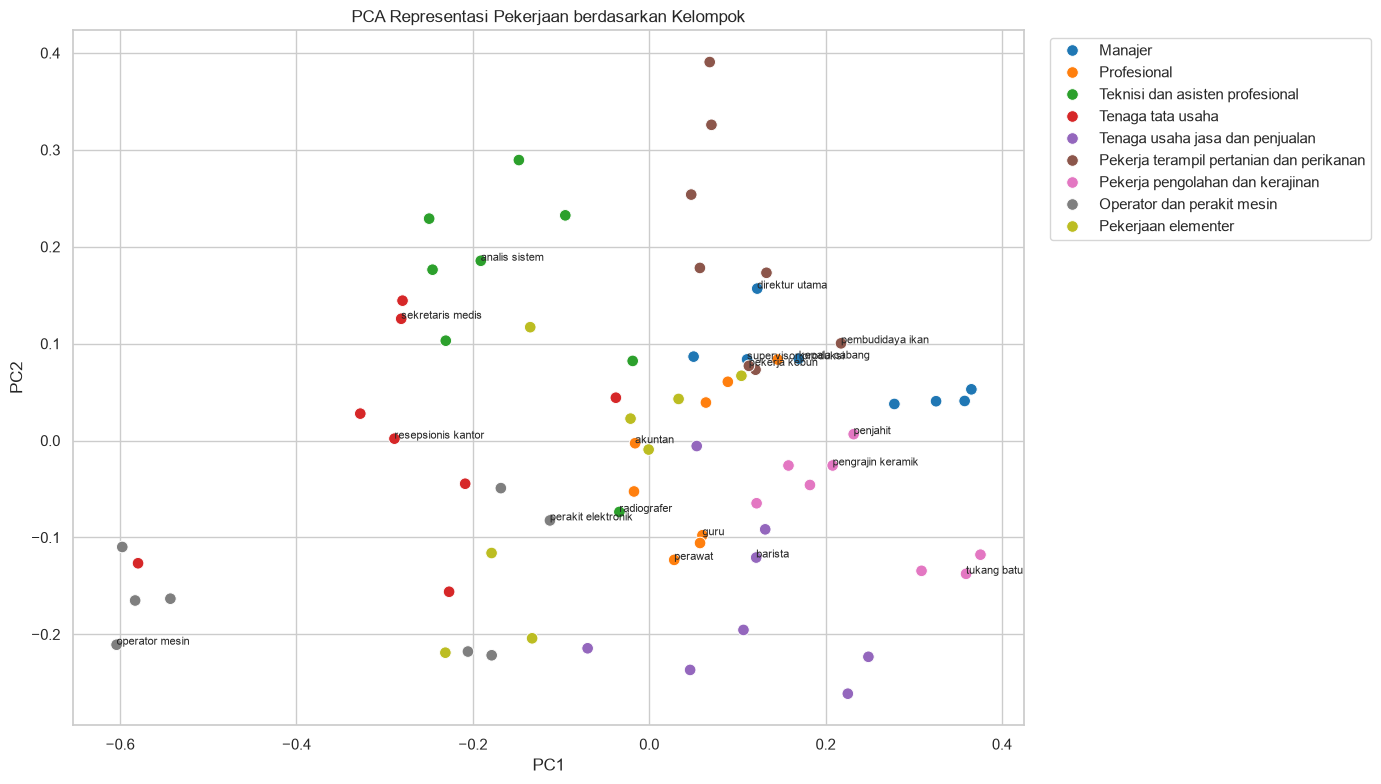

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.scatterplot(data=occupation_coordinates, x="PC1", y="PC2", hue="major_group_name", palette="tab10", s=70, ax=ax)
for _, row in occupation_coordinates.sample(18, random_state=RANDOM_SEED).iterrows():
    ax.text(row.PC1, row.PC2, row.occupation_name, fontsize=8)
ax.set(title="PCA Representasi Pekerjaan berdasarkan Kelompok", xlabel="PC1", ylabel="PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

## 7. Perhitungan cosine similarity pekerjaan–gender

In [10]:
male_mask = df_istilah_gender["gender_group"].eq("laki-laki").to_numpy()
female_mask = df_istilah_gender["gender_group"].eq("perempuan").to_numpy()
male_vectors = term_vectors[male_mask]
female_vectors = term_vectors[female_mask]
male_terms = df_istilah_gender.loc[male_mask, "term"].tolist()
female_terms = df_istilah_gender.loc[female_mask, "term"].tolist()

male_similarity_matrix = cosine_similarity(occupation_vectors, male_vectors)
female_similarity_matrix = cosine_similarity(occupation_vectors, female_vectors)
all_gender_similarity = np.hstack([male_similarity_matrix, female_similarity_matrix])

similarity_results = df_pekerjaan[["occupation_id", "occupation_name", "major_group_name"]].copy()
similarity_results["mean_male_similarity"] = male_similarity_matrix.mean(axis=1)
similarity_results["mean_female_similarity"] = female_similarity_matrix.mean(axis=1)
similarity_results["similarity_difference"] = similarity_results["mean_male_similarity"] - similarity_results["mean_female_similarity"]
display(similarity_results.head(10).round(4))
display(similarity_results.nlargest(TOP_N, "mean_male_similarity").round(4))
display(similarity_results.nlargest(TOP_N, "mean_female_similarity").round(4))

,occupation_id,occupation_name,major_group_name,mean_male_similarity,mean_female_similarity,similarity_difference
0,101,direktur utama,Manajer,-0.0497,0.0777,-0.1274
1,102,manajer operasional,Manajer,0.0125,-0.0267,0.0393
2,103,manajer keuangan,Manajer,-0.0053,-0.0120,0.0067
3,104,manajer pemasaran,Manajer,0.0202,-0.0159,0.0361
4,105,kepala cabang,Manajer,0.0012,0.0558,-0.0547
5,106,supervisor produksi,Manajer,0.0075,0.0589,-0.0514
6,107,koordinator proyek,Manajer,-0.0204,-0.0003,-0.0201
7,108,manajer sumber daya manusia,Manajer,0.0122,0.0120,0.0002
8,201,dokter,Profesional,-0.0181,0.0060,-0.0241
9,202,perawat,Profesional,-0.0113,-0.0036,-0.0076


,occupation_id,occupation_name,major_group_name,mean_male_similarity,mean_female_similarity,similarity_difference
39,508,pelayan toko,Tenaga usaha jasa dan penjualan,0.0607,-0.0271,0.0878
22,307,radiografer,Teknisi dan asisten profesional,0.0540,-0.0167,0.0707
32,501,kasir,Tenaga usaha jasa dan penjualan,0.0499,-0.0250,0.0749
38,507,petugas layanan pelanggan,Tenaga usaha jasa dan penjualan,0.0390,-0.0104,0.0494
44,605,nelayan tangkap,Pekerja terampil pertanian dan perikanan,0.0386,0.0050,0.0337
58,803,pengemudi truk,Operator dan perakit mesin,0.0375,-0.0262,0.0638
59,804,pengemudi bus,Operator dan perakit mesin,0.0363,-0.0388,0.0751
70,907,pekerja bongkar muat,Pekerjaan elementer,0.0275,0.0042,0.0233
66,903,buruh angkut,Pekerjaan elementer,0.0265,-0.0392,0.0657
45,606,pembudidaya ikan,Pekerja terampil pertanian dan perikanan,0.0216,-0.0075,0.0291


,occupation_id,occupation_name,major_group_name,mean_male_similarity,mean_female_similarity,similarity_difference
68,905,pemulung,Pekerjaan elementer,-0.0427,0.0782,-0.1209
0,101,direktur utama,Manajer,-0.0497,0.0777,-0.1274
23,308,asisten apoteker,Teknisi dan asisten profesional,0.0149,0.0689,-0.0540
42,603,peternak sapi,Pekerja terampil pertanian dan perikanan,-0.0442,0.0648,-0.1090
5,106,supervisor produksi,Manajer,0.0075,0.0589,-0.0514
33,502,pramusaji,Tenaga usaha jasa dan penjualan,-0.0372,0.0582,-0.0954
4,105,kepala cabang,Manajer,0.0012,0.0558,-0.0547
60,805,masinis,Operator dan perakit mesin,0.0088,0.0553,-0.0466
52,705,pengrajin mebel,Pekerja pengolahan dan kerajinan,0.0211,0.0546,-0.0335
43,604,peternak unggas,Pekerja terampil pertanian dan perikanan,-0.0347,0.0528,-0.0875


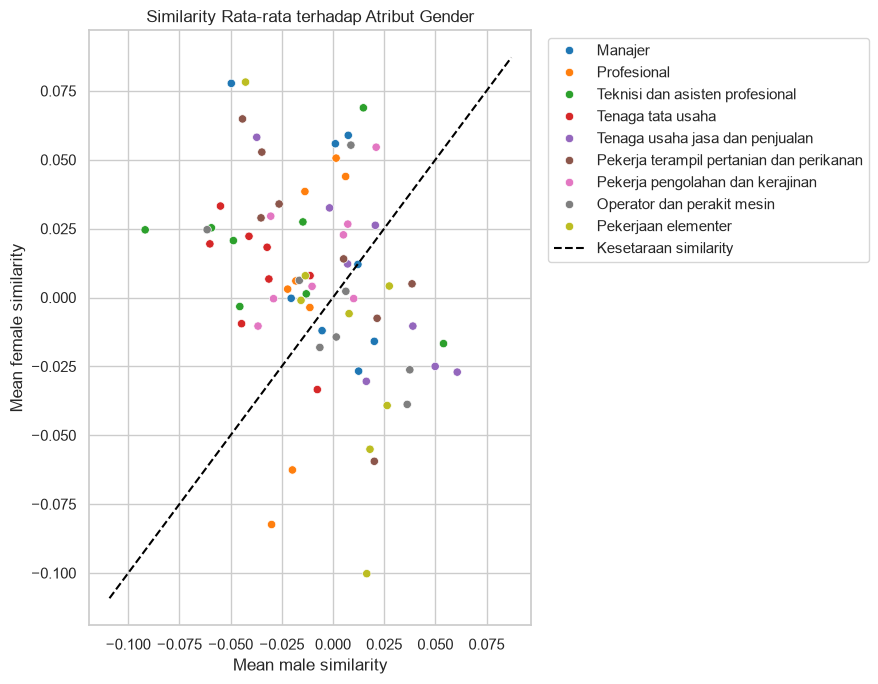

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=similarity_results, x="mean_male_similarity", y="mean_female_similarity", hue="major_group_name", palette="tab10", ax=ax)
lower = min(ax.get_xlim()[0], ax.get_ylim()[0])
upper = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lower, upper], [lower, upper], linestyle="--", color="black", label="Kesetaraan similarity")
ax.set(title="Similarity Rata-rata terhadap Atribut Gender", xlabel="Mean male similarity", ylabel="Mean female similarity")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

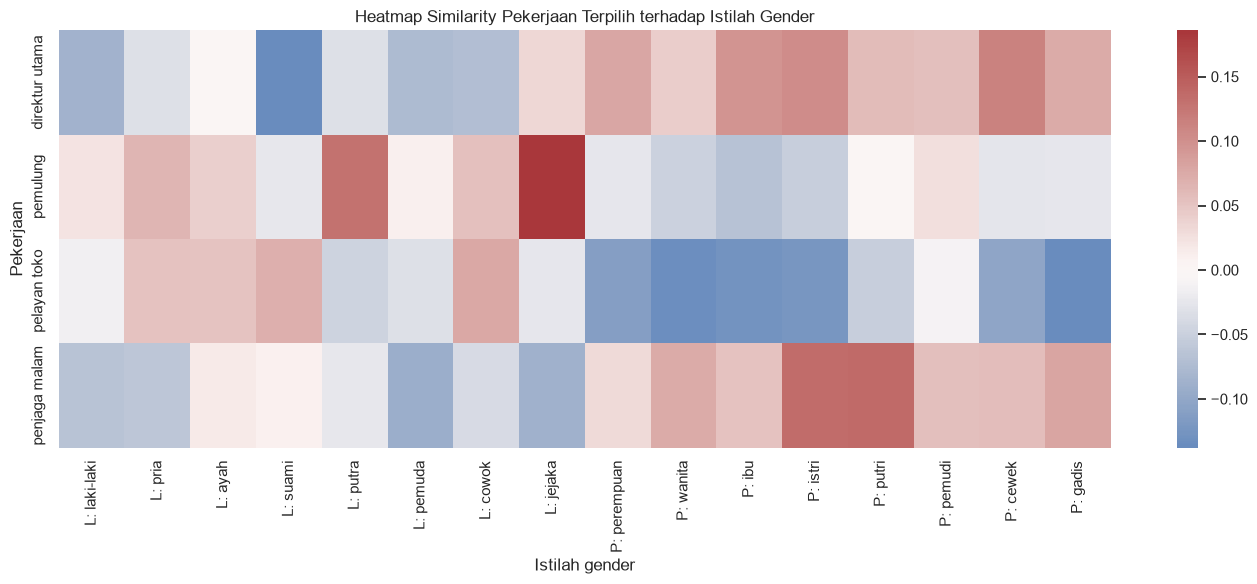

In [12]:
selected_occupations = similarity_results.sort_values("similarity_difference").iloc[[0, 1, -2, -1]]["occupation_name"].tolist()
selected_indices = df_pekerjaan.index[df_pekerjaan["occupation_name"].isin(selected_occupations)].tolist()
heatmap_values = all_gender_similarity[selected_indices]
heatmap_columns = [f"L: {term}" for term in male_terms] + [f"P: {term}" for term in female_terms]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pd.DataFrame(heatmap_values, index=selected_occupations, columns=heatmap_columns), cmap="vlag", center=0, annot=False, ax=ax)
ax.set(title="Heatmap Similarity Pekerjaan Terpilih terhadap Istilah Gender", xlabel="Istilah gender", ylabel="Pekerjaan")
fig.tight_layout()
display(fig)
plt.close(fig)

## Visualisasi tambahan: perbandingan langsung similarity

Setiap garis menghubungkan rata-rata similarity terhadap atribut perempuan dan laki-laki. Pekerjaan yang dipilih adalah delapan pekerjaan dengan selisih absolut terbesar.

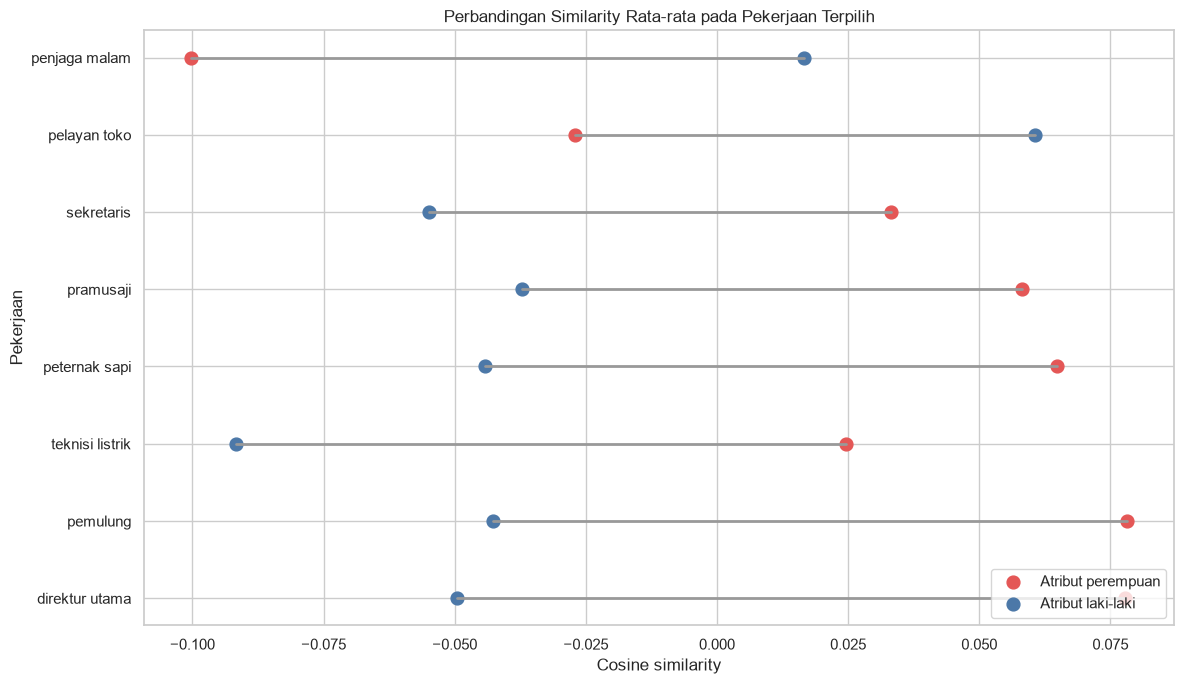

In [13]:
similarity_subset = similarity_results.loc[
    similarity_results["similarity_difference"].abs().nlargest(8).index
].sort_values("similarity_difference").reset_index(drop=True)
y_positions = np.arange(len(similarity_subset))
fig, ax = plt.subplots(figsize=(12, 7))
for y, row in similarity_subset.iterrows():
    ax.plot([row["mean_female_similarity"], row["mean_male_similarity"]], [y, y], color="#999999", linewidth=2)
ax.scatter(similarity_subset["mean_female_similarity"], y_positions, color="#E45756", s=85, label="Atribut perempuan")
ax.scatter(similarity_subset["mean_male_similarity"], y_positions, color="#4C78A8", s=85, label="Atribut laki-laki")
ax.set_yticks(y_positions)
ax.set_yticklabels(similarity_subset["occupation_name"])
ax.set(title="Perbandingan Similarity Rata-rata pada Pekerjaan Terpilih", xlabel="Cosine similarity", ylabel="Pekerjaan")
ax.legend(loc="lower right")
fig.tight_layout()
display(fig)
plt.close(fig)

## 8. SC-WEAT per pekerjaan

SC-WEAT menghitung selisih rata-rata cosine terhadap atribut laki-laki dan perempuan, lalu membaginya dengan sample standard deviation seluruh similarity terhadap kedua kelompok atribut. Sample standard deviation (ddof=1) digunakan secara konsisten.

In [14]:
def calculate_sc_weat(occupation_vector, male_vectors, female_vectors):
    male_similarity = cosine_similarity(occupation_vector.reshape(1, -1), male_vectors).ravel()
    female_similarity = cosine_similarity(occupation_vector.reshape(1, -1), female_vectors).ravel()
    all_similarity = np.concatenate([male_similarity, female_similarity])
    association_difference = float(male_similarity.mean() - female_similarity.mean())
    standard_deviation = float(np.std(all_similarity, ddof=1))
    effect_size = np.nan if standard_deviation == 0 or not np.isfinite(standard_deviation) else association_difference / standard_deviation
    return {"mean_male_similarity": male_similarity.mean(), "mean_female_similarity": female_similarity.mean(), "association_difference": association_difference, "scweat_effect_size": effect_size}

In [15]:
scweat_rows = []
for row, vector in zip(df_pekerjaan.itertuples(index=False), occupation_vectors):
    scores = calculate_sc_weat(vector, male_vectors, female_vectors)
    effect = scores["scweat_effect_size"]
    scweat_rows.append({
        "occupation_id": row.occupation_id,
        "occupation_name": row.occupation_name,
        "major_group_code": row.major_group_code,
        "major_group_name": row.major_group_name,
        **scores,
        "association_direction": "positif" if effect > 0 else "negatif" if effect < 0 else "mendekati nol",
    })
scweat_results = pd.DataFrame(scweat_rows)
display(scweat_results.head(10).round(4))

,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction
0,101,direktur utama,1,Manajer,-0.0497,0.0777,-0.1274,-1.6480,negatif
1,102,manajer operasional,1,Manajer,0.0125,-0.0267,0.0393,0.7525,positif
2,103,manajer keuangan,1,Manajer,-0.0053,-0.0120,0.0067,0.2004,positif
3,104,manajer pemasaran,1,Manajer,0.0202,-0.0159,0.0361,0.6185,positif
4,105,kepala cabang,1,Manajer,0.0012,0.0558,-0.0547,-0.8771,negatif
5,106,supervisor produksi,1,Manajer,0.0075,0.0589,-0.0514,-0.9547,negatif
6,107,koordinator proyek,1,Manajer,-0.0204,-0.0003,-0.0201,-0.4939,negatif
7,108,manajer sumber daya manusia,1,Manajer,0.0122,0.0120,0.0002,0.0044,positif
8,201,dokter,2,Profesional,-0.0181,0.0060,-0.0241,-0.3780,negatif
9,202,perawat,2,Profesional,-0.0113,-0.0036,-0.0076,-0.1513,negatif


## 9. Permutation test dan koreksi FDR

Untuk setiap pekerjaan, pembagian delapan atribut laki-laki dan delapan atribut perempuan diacak. P-value two-sided dikoreksi menggunakan Benjamini–Hochberg.

In [16]:
permutation_rows = []
for row_index, row in scweat_results.iterrows():
    observed = float(row["association_difference"])
    observed_similarity = all_gender_similarity[row_index]
    permutation_rng = np.random.default_rng(RANDOM_SEED + row_index)
    null_statistics = []
    for _ in range(N_PERMUTATIONS):
        shuffled = permutation_rng.permutation(observed_similarity)
        null_statistics.append(shuffled[:len(male_terms)].mean() - shuffled[len(male_terms):].mean())
    p_value = (1 + np.count_nonzero(np.abs(null_statistics) >= abs(observed))) / (1 + N_PERMUTATIONS)
    permutation_rows.append({"occupation_id": row.occupation_id, "p_value": p_value, "n_permutations": N_PERMUTATIONS, "random_seed": RANDOM_SEED + row_index})

permutation_results = pd.DataFrame(permutation_rows)
reject_fdr, adjusted_p_values, _, _ = multipletests(permutation_results["p_value"], alpha=ALPHA, method="fdr_bh")
permutation_results["adjusted_p_value"] = adjusted_p_values
permutation_results["significant_raw"] = permutation_results["p_value"] < ALPHA
permutation_results["significant_fdr"] = reject_fdr
scweat_results = scweat_results.merge(permutation_results, on="occupation_id", validate="one_to_one")
print("Signifikan sebelum koreksi:", int(permutation_results["significant_raw"].sum()))
print("Signifikan setelah FDR:", int(permutation_results["significant_fdr"].sum()))
display(scweat_results.nsmallest(TOP_N, "adjusted_p_value").round(4))

Signifikan sebelum koreksi: 26
Signifikan setelah FDR: 15


,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction,p_value,n_permutations,random_seed,adjusted_p_value,significant_raw,significant_fdr
0,101,direktur utama,1,Manajer,-0.0497,0.0777,-0.1274,-1.6480,negatif,0.0005,2000,42,0.0072,True,True
16,301,teknisi listrik,3,Teknisi dan asisten profesional,-0.0917,0.0246,-0.1163,-1.5411,negatif,0.0005,2000,58,0.0072,True,True
39,508,pelayan toko,5,Tenaga usaha jasa dan penjualan,0.0607,-0.0271,0.0878,1.2929,positif,0.0005,2000,81,0.0072,True,True
67,904,penjaga malam,9,Pekerjaan elementer,0.0165,-0.1002,0.1167,1.5316,positif,0.0005,2000,109,0.0072,True,True
68,905,pemulung,9,Pekerjaan elementer,-0.0427,0.0782,-0.1209,-1.6471,negatif,0.0005,2000,110,0.0072,True,True
29,406,staf keuangan,4,Tenaga tata usaha,-0.0410,0.0222,-0.0633,-1.3577,negatif,0.0030,2000,71,0.0270,True,True
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,-0.0372,0.0582,-0.0954,-1.5326,negatif,0.0025,2000,75,0.0270,True,True
43,604,peternak unggas,6,Pekerja terampil pertanian dan perikanan,-0.0347,0.0528,-0.0875,-1.2734,negatif,0.0030,2000,85,0.0270,True,True
42,603,peternak sapi,6,Pekerja terampil pertanian dan perikanan,-0.0442,0.0648,-0.1090,-1.3846,negatif,0.0035,2000,84,0.0280,True,True
22,307,radiografer,3,Teknisi dan asisten profesional,0.0540,-0.0167,0.0707,1.2584,positif,0.0040,2000,64,0.0288,True,True


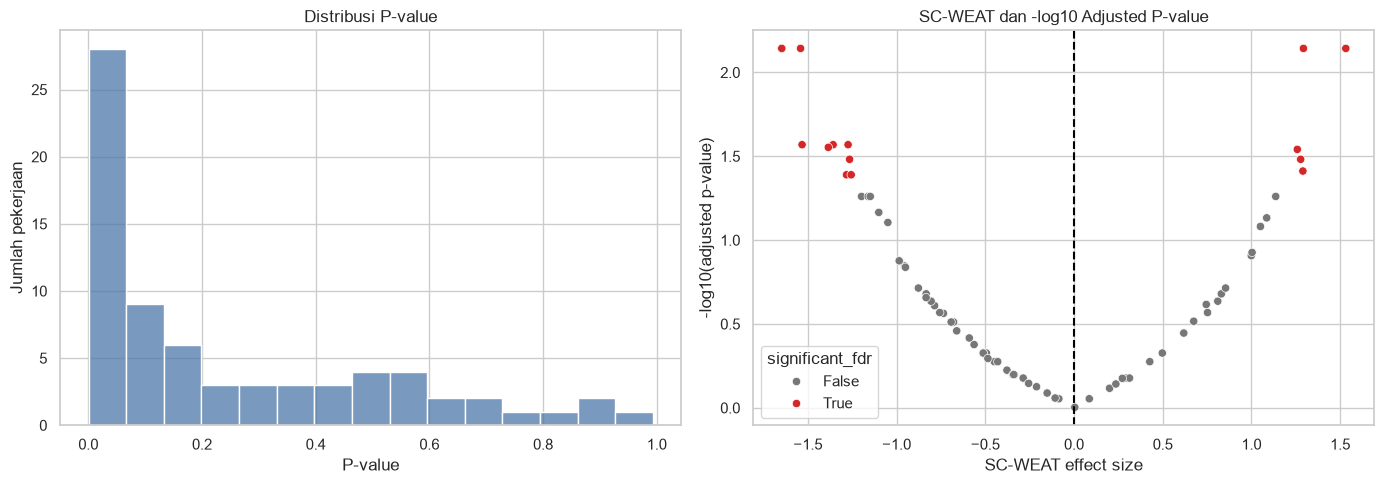

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(permutation_results["p_value"], bins=15, ax=axes[0], color="#4C78A8")
axes[0].set(title="Distribusi P-value", xlabel="P-value", ylabel="Jumlah pekerjaan")
plot_results = scweat_results.assign(minus_log10_adjusted_p=-np.log10(scweat_results["adjusted_p_value"].clip(lower=np.finfo(float).tiny)))
sns.scatterplot(data=plot_results, x="scweat_effect_size", y="minus_log10_adjusted_p", hue="significant_fdr", palette={True: "#D62728", False: "#777777"}, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="SC-WEAT dan -log10 Adjusted P-value", xlabel="SC-WEAT effect size", ylabel="-log10(adjusted p-value)")
fig.tight_layout()
display(fig)
plt.close(fig)

## 10. Analisis pekerjaan

Gunakan istilah asosiasi relatif. Jangan memberikan label normatif pada pekerjaan.

In [18]:
print("Asosiasi relatif positif tertinggi")
display(scweat_results.nlargest(TOP_N, "scweat_effect_size").round(4))
print("Asosiasi relatif negatif terendah")
display(scweat_results.nsmallest(TOP_N, "scweat_effect_size").round(4))
print("Effect size paling dekat dengan nol")
display(scweat_results.iloc[scweat_results["scweat_effect_size"].abs().argsort()[:TOP_N]].round(4))
display(scweat_results.sort_values("scweat_effect_size").round(4))

Asosiasi relatif positif tertinggi


,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction,p_value,n_permutations,random_seed,adjusted_p_value,significant_raw,significant_fdr
67,904,penjaga malam,9,Pekerjaan elementer,0.0165,-0.1002,0.1167,1.5316,positif,0.0005,2000,109,0.0072,True,True
39,508,pelayan toko,5,Tenaga usaha jasa dan penjualan,0.0607,-0.0271,0.0878,1.2929,positif,0.0005,2000,81,0.0072,True,True
32,501,kasir,5,Tenaga usaha jasa dan penjualan,0.0499,-0.0250,0.0749,1.2897,positif,0.0070,2000,74,0.0387,True,True
64,901,petugas kebersihan,9,Pekerjaan elementer,0.0181,-0.0551,0.0732,1.2774,positif,0.0055,2000,106,0.0330,True,True
22,307,radiografer,3,Teknisi dan asisten profesional,0.0540,-0.0167,0.0707,1.2584,positif,0.0040,2000,64,0.0288,True,True
47,608,pekerja kebun,6,Pekerja terampil pertanian dan perikanan,0.0202,-0.0595,0.0797,1.1367,positif,0.0125,2000,89,0.0549,True,False
15,208,arsitek,2,Profesional,-0.0300,-0.0824,0.0524,1.0859,positif,0.0215,2000,57,0.0737,True,False
59,804,pengemudi bus,8,Operator dan perakit mesin,0.0363,-0.0388,0.0751,1.0506,positif,0.0265,2000,101,0.0829,True,False
66,903,buruh angkut,9,Pekerjaan elementer,0.0265,-0.0392,0.0657,1.0035,positif,0.0395,2000,108,0.1184,True,False
58,803,pengemudi truk,8,Operator dan perakit mesin,0.0375,-0.0262,0.0638,0.9989,positif,0.0430,2000,100,0.1238,True,False


Asosiasi relatif negatif terendah


,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction,p_value,n_permutations,random_seed,adjusted_p_value,significant_raw,significant_fdr
0,101,direktur utama,1,Manajer,-0.0497,0.0777,-0.1274,-1.6480,negatif,0.0005,2000,42,0.0072,True,True
68,905,pemulung,9,Pekerjaan elementer,-0.0427,0.0782,-0.1209,-1.6471,negatif,0.0005,2000,110,0.0072,True,True
16,301,teknisi listrik,3,Teknisi dan asisten profesional,-0.0917,0.0246,-0.1163,-1.5411,negatif,0.0005,2000,58,0.0072,True,True
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,-0.0372,0.0582,-0.0954,-1.5326,negatif,0.0025,2000,75,0.0270,True,True
42,603,peternak sapi,6,Pekerja terampil pertanian dan perikanan,-0.0442,0.0648,-0.1090,-1.3846,negatif,0.0035,2000,84,0.0280,True,True
29,406,staf keuangan,4,Tenaga tata usaha,-0.0410,0.0222,-0.0633,-1.3577,negatif,0.0030,2000,71,0.0270,True,True
24,401,sekretaris,4,Tenaga tata usaha,-0.0550,0.0332,-0.0881,-1.2823,negatif,0.0085,2000,66,0.0408,True,True
43,604,peternak unggas,6,Pekerja terampil pertanian dan perikanan,-0.0347,0.0528,-0.0875,-1.2734,negatif,0.0030,2000,85,0.0270,True,True
31,408,sekretaris medis,4,Tenaga tata usaha,-0.0601,0.0195,-0.0796,-1.2649,negatif,0.0055,2000,73,0.0330,True,True
61,806,operator pabrik,8,Operator dan perakit mesin,-0.0615,0.0246,-0.0861,-1.2558,negatif,0.0085,2000,103,0.0408,True,True


Effect size paling dekat dengan nol


,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction,p_value,n_permutations,random_seed,adjusted_p_value,significant_raw,significant_fdr
7,108,manajer sumber daya manusia,1,Manajer,0.0122,0.0120,0.0002,0.0044,positif,0.9930,2000,49,0.9930,False,False
34,503,barista,5,Tenaga usaha jasa dan penjualan,0.0071,0.0122,-0.0051,-0.0856,negatif,0.8706,2000,76,0.8828,False,False
56,801,operator mesin,8,Operator dan perakit mesin,0.0063,0.0023,0.0040,0.0860,positif,0.8636,2000,98,0.8828,False,False
37,506,tenaga penjualan,5,Tenaga usaha jasa dan penjualan,0.0207,0.0262,-0.0055,-0.1065,negatif,0.8376,2000,79,0.8740,False,False
9,202,perawat,2,Profesional,-0.0113,-0.0036,-0.0076,-0.1513,negatif,0.7706,2000,51,0.8159,False,False
2,103,manajer keuangan,1,Manajer,-0.0053,-0.0120,0.0067,0.2004,positif,0.7111,2000,44,0.7642,False,False
41,602,pekebun hortikultura,6,Pekerja terampil pertanian dan perikanan,0.0052,0.0140,-0.0088,-0.2112,negatif,0.6862,2000,83,0.7485,False,False
49,702,tukang batu,7,Pekerja pengolahan dan kerajinan,0.0101,-0.0004,0.0105,0.2358,positif,0.6507,2000,91,0.7207,False,False
54,707,pengrajin keramik,7,Pekerja pengolahan dan kerajinan,0.0051,0.0227,-0.0176,-0.2558,negatif,0.6352,2000,96,0.7146,False,False
69,906,pencuci kendaraan,9,Pekerjaan elementer,0.0079,-0.0059,0.0137,0.2724,positif,0.5837,2000,111,0.6671,False,False


,occupation_id,occupation_name,major_group_code,major_group_name,mean_male_similarity,mean_female_similarity,association_difference,scweat_effect_size,association_direction,p_value,n_permutations,random_seed,adjusted_p_value,significant_raw,significant_fdr
0,101,direktur utama,1,Manajer,-0.0497,0.0777,-0.1274,-1.6480,negatif,0.0005,2000,42,0.0072,True,True
68,905,pemulung,9,Pekerjaan elementer,-0.0427,0.0782,-0.1209,-1.6471,negatif,0.0005,2000,110,0.0072,True,True
16,301,teknisi listrik,3,Teknisi dan asisten profesional,-0.0917,0.0246,-0.1163,-1.5411,negatif,0.0005,2000,58,0.0072,True,True
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,-0.0372,0.0582,-0.0954,-1.5326,negatif,0.0025,2000,75,0.0270,True,True
42,603,peternak sapi,6,Pekerja terampil pertanian dan perikanan,-0.0442,0.0648,-0.1090,-1.3846,negatif,0.0035,2000,84,0.0280,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,307,radiografer,3,Teknisi dan asisten profesional,0.0540,-0.0167,0.0707,1.2584,positif,0.0040,2000,64,0.0288,True,True
64,901,petugas kebersihan,9,Pekerjaan elementer,0.0181,-0.0551,0.0732,1.2774,positif,0.0055,2000,106,0.0330,True,True
32,501,kasir,5,Tenaga usaha jasa dan penjualan,0.0499,-0.0250,0.0749,1.2897,positif,0.0070,2000,74,0.0387,True,True
39,508,pelayan toko,5,Tenaga usaha jasa dan penjualan,0.0607,-0.0271,0.0878,1.2929,positif,0.0005,2000,81,0.0072,True,True


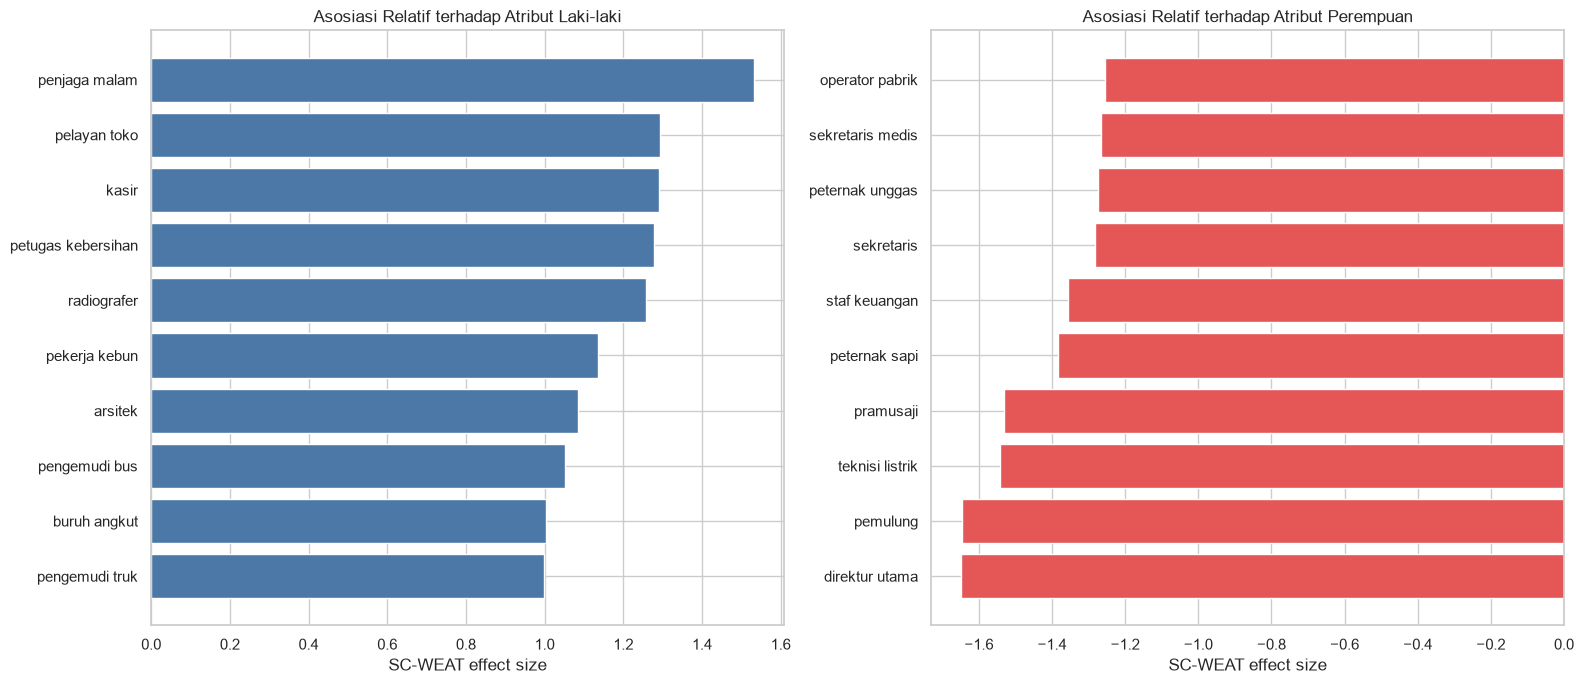

In [19]:
positive_top = scweat_results.nlargest(TOP_N, "scweat_effect_size").sort_values("scweat_effect_size")
negative_top = scweat_results.nsmallest(TOP_N, "scweat_effect_size").sort_values("scweat_effect_size")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(positive_top["occupation_name"], positive_top["scweat_effect_size"], color="#4C78A8")
axes[0].set(title="Asosiasi Relatif terhadap Atribut Laki-laki", xlabel="SC-WEAT effect size")
axes[1].barh(negative_top["occupation_name"], negative_top["scweat_effect_size"], color="#E45756")
axes[1].set(title="Asosiasi Relatif terhadap Atribut Perempuan", xlabel="SC-WEAT effect size")
fig.tight_layout()
display(fig)
plt.close(fig)

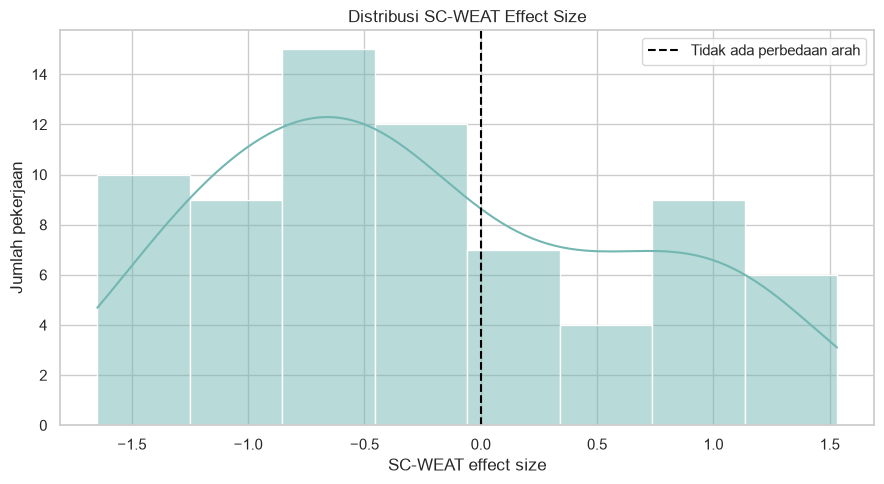

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(scweat_results["scweat_effect_size"], kde=True, ax=ax, color="#72B7B2")
ax.axvline(0, color="black", linestyle="--", label="Tidak ada perbedaan arah")
ax.set(title="Distribusi SC-WEAT Effect Size", xlabel="SC-WEAT effect size", ylabel="Jumlah pekerjaan")
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## Visualisasi tambahan: peta arah dan besar asosiasi

Sumbu horizontal menunjukkan selisih similarity sebelum standardisasi, sedangkan sumbu vertikal menunjukkan effect size SC-WEAT. Garis nol membantu membaca arah asosiasi relatif.

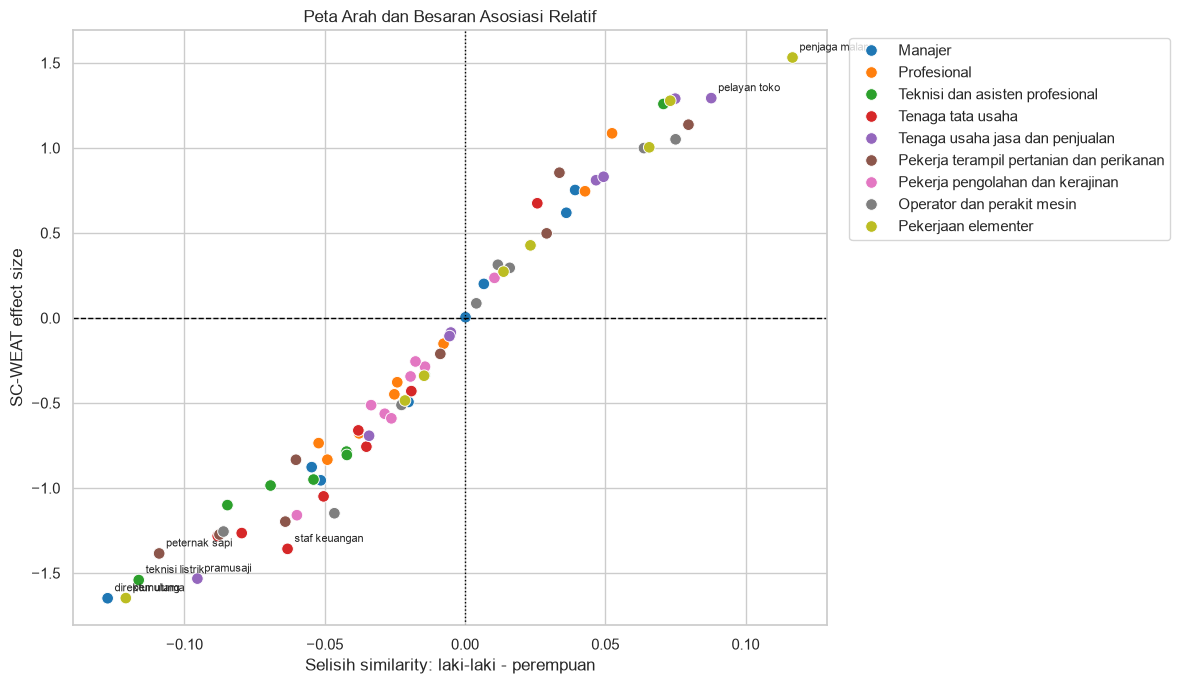

In [21]:
association_map = scweat_results.copy()
association_map["similarity_difference"] = association_map["mean_male_similarity"] - association_map["mean_female_similarity"]
association_map["absolute_effect_size"] = association_map["scweat_effect_size"].abs()
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(data=association_map, x="similarity_difference", y="scweat_effect_size", hue="major_group_name", palette="tab10", s=70, ax=ax)
for _, row in association_map.nlargest(8, "absolute_effect_size").iterrows():
    ax.annotate(row["occupation_name"], (row["similarity_difference"], row["scweat_effect_size"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.set(title="Peta Arah dan Besaran Asosiasi Relatif", xlabel="Selisih similarity: laki-laki - perempuan", ylabel="SC-WEAT effect size")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Ringkasan kelompok pekerjaan

Ringkasan berikut menggambarkan pola representasi embedding per kelompok. Perbedaan tidak ditafsirkan sebagai kondisi sosial nyata.

In [22]:
group_summary = scweat_results.groupby("major_group_name", sort=False).agg(
    occupation_count=("occupation_id", "count"),
    mean_effect_size=("scweat_effect_size", "mean"),
    median_effect_size=("scweat_effect_size", "median"),
    std_effect_size=("scweat_effect_size", "std"),
    minimum_effect_size=("scweat_effect_size", "min"),
    maximum_effect_size=("scweat_effect_size", "max"),
    positive_proportion=("scweat_effect_size", lambda values: (values > 0).mean()),
    negative_proportion=("scweat_effect_size", lambda values: (values < 0).mean()),
    significant_fdr_count=("significant_fdr", "sum"),
).reset_index()
display(group_summary.round(4))

,major_group_name,occupation_count,mean_effect_size,median_effect_size,std_effect_size,minimum_effect_size,maximum_effect_size,positive_proportion,negative_proportion,significant_fdr_count
0,Manajer,8,-0.2997,-0.2448,0.8376,-1.6480,0.7525,0.500,0.500,1
1,Profesional,8,-0.1744,-0.4135,0.7126,-0.8332,1.0859,0.250,0.750,0
2,Teknisi dan asisten profesional,8,-0.6557,-0.8778,0.8436,-1.5411,1.2584,0.125,0.875,2
3,Tenaga tata usaha,8,-0.7659,-0.9029,0.6703,-1.3577,0.6746,0.125,0.875,3
4,Tenaga usaha jasa dan penjualan,8,0.2257,0.3623,1.0086,-1.5326,1.2929,0.500,0.500,3
5,Pekerja terampil pertanian dan perikanan,8,-0.3015,-0.5225,1.0180,-1.3846,1.1367,0.375,0.625,2
6,Pekerja pengolahan dan kerajinan,8,-0.4345,-0.4283,0.3936,-1.1597,0.2358,0.125,0.875,0
7,Operator dan perakit mesin,8,-0.0215,0.1904,0.8821,-1.2558,1.0506,0.625,0.375,1
8,Pekerjaan elementer,8,0.2550,0.3497,1.0546,-1.6471,1.5316,0.625,0.375,3


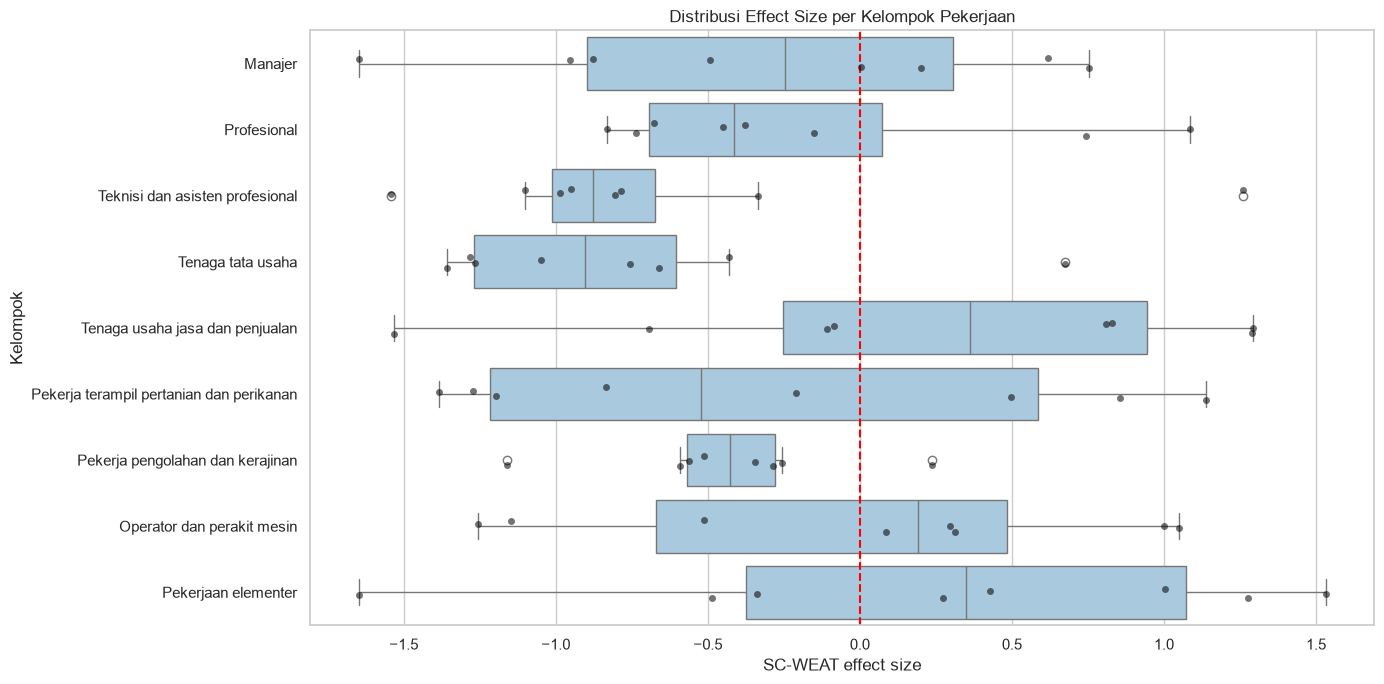

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=scweat_results, x="scweat_effect_size", y="major_group_name", color="#A0CBE8", ax=ax)
sns.stripplot(data=scweat_results, x="scweat_effect_size", y="major_group_name", color="black", alpha=.55, ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set(title="Distribusi Effect Size per Kelompok Pekerjaan", xlabel="SC-WEAT effect size", ylabel="Kelompok")
fig.tight_layout()
display(fig)
plt.close(fig)
plt.show()

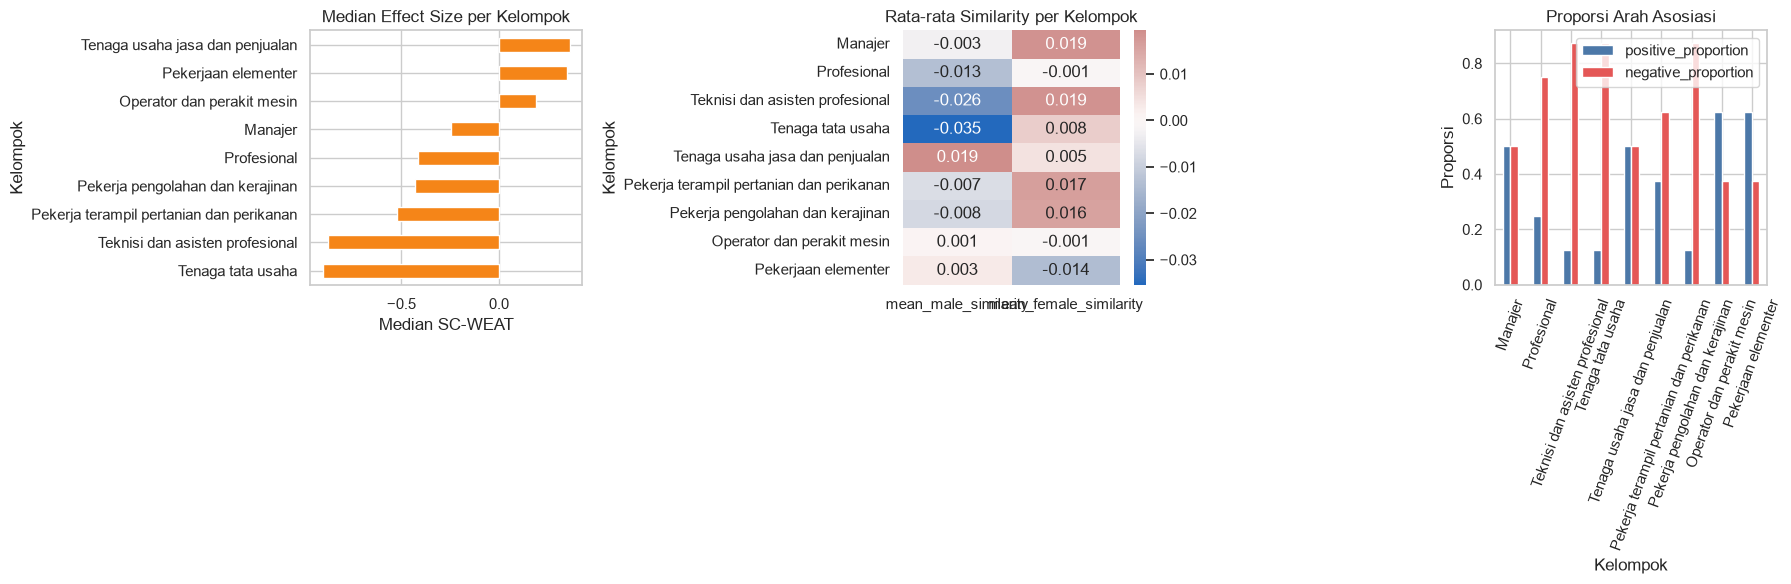

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
group_summary.sort_values("median_effect_size").plot.barh(x="major_group_name", y="median_effect_size", legend=False, color="#F58518", ax=axes[0])
axes[0].set(title="Median Effect Size per Kelompok", xlabel="Median SC-WEAT", ylabel="Kelompok")
group_similarity = scweat_results.groupby("major_group_name", sort=False)[["mean_male_similarity", "mean_female_similarity"]].mean()
sns.heatmap(group_similarity, annot=True, fmt=".3f", cmap="vlag", center=0, ax=axes[1])
axes[1].set(title="Rata-rata Similarity per Kelompok", xlabel="", ylabel="Kelompok")
direction_table = group_summary.set_index("major_group_name")[["positive_proportion", "negative_proportion"]]
direction_table.plot.bar(ax=axes[2], color=["#4C78A8", "#E45756"])
axes[2].set(title="Proporsi Arah Asosiasi", xlabel="Kelompok", ylabel="Proporsi")
axes[2].tick_params(axis="x", rotation=70)
fig.tight_layout()
display(fig)
plt.close(fig)

## Visualisasi tambahan: ringkasan arah asosiasi

Grafik ini menunjukkan berapa banyak pekerjaan yang berada di sisi positif, mendekati nol, atau negatif. Kategori tersebut hanya merangkum arah hasil embedding.

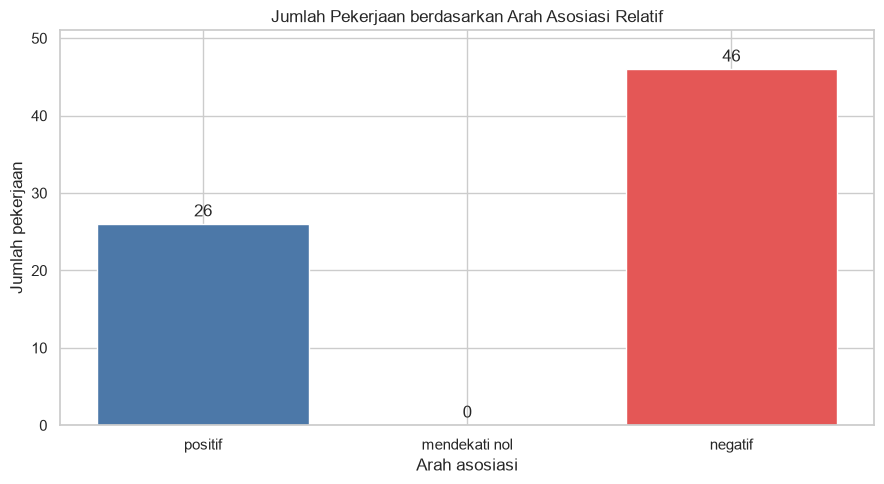

In [25]:
direction_counts = scweat_results["association_direction"].value_counts().reindex(["positif", "mendekati nol", "negatif"]).fillna(0)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(direction_counts.index, direction_counts.values, color=["#4C78A8", "#BDBDBD", "#E45756"])
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(title="Jumlah Pekerjaan berdasarkan Arah Asosiasi Relatif", xlabel="Arah asosiasi", ylabel="Jumlah pekerjaan")
ax.set_ylim(0, max(direction_counts.values) + 5)
fig.tight_layout()
display(fig)
plt.close(fig)

## 12. Analisis sensitivitas sebagai quality control

Satu pasangan istilah gender dikeluarkan pada setiap kondisi. Skor seluruh pekerjaan dihitung ulang, lalu dibandingkan dengan baseline.

In [26]:
baseline_effects = scweat_results.set_index("occupation_id")["scweat_effect_size"]
sensitivity_rows = []
sensitivity_effect_matrix = []
for pair_id in df_istilah_gender["pair_id"].drop_duplicates():
    keep_terms = df_istilah_gender["pair_id"] != pair_id
    keep_male = keep_terms & male_mask
    keep_female = keep_terms & female_mask
    reduced_male_vectors = term_vectors[keep_male]
    reduced_female_vectors = term_vectors[keep_female]
    reduced_effects = []
    for vector in occupation_vectors:
        reduced_effects.append(calculate_sc_weat(vector, reduced_male_vectors, reduced_female_vectors)["scweat_effect_size"])
    reduced_effects = np.array(reduced_effects)
    effect_change = reduced_effects - baseline_effects.to_numpy()
    sensitivity_effect_matrix.append(effect_change)
    sensitivity_rows.append({
        "excluded_pair_id": pair_id,
        "excluded_terms": ", ".join(df_istilah_gender.loc[df_istilah_gender["pair_id"] == pair_id, "term"]),
        "spearman_rank_correlation": spearmanr(baseline_effects.to_numpy(), reduced_effects).statistic,
        "mean_absolute_change": np.mean(np.abs(effect_change)),
        "direction_preserved_proportion": np.mean(np.sign(reduced_effects) == np.sign(baseline_effects.to_numpy())),
        "sign_change_count": np.count_nonzero(np.sign(reduced_effects) != np.sign(baseline_effects.to_numpy())),
    })
sensitivity_results = pd.DataFrame(sensitivity_rows)
sensitivity_effect_matrix = pd.DataFrame(sensitivity_effect_matrix, index=sensitivity_results["excluded_pair_id"], columns=scweat_results["occupation_name"])
display(sensitivity_results.round(4))

,excluded_pair_id,excluded_terms,spearman_rank_correlation,mean_absolute_change,direction_preserved_proportion,sign_change_count
0,G01,"laki-laki, perempuan",0.9717,0.1418,0.9722,2
1,G02,"pria, wanita",0.9887,0.0944,1.0000,0
2,G03,"ayah, ibu",0.9716,0.1376,0.9444,4
3,G04,"suami, istri",0.9803,0.1113,0.9444,4
4,G05,"putra, putri",0.9830,0.1247,0.9306,5
5,G06,"pemuda, pemudi",0.9833,0.1201,0.9861,1
6,G07,"cowok, cewek",0.9756,0.1360,0.9444,4
7,G08,"jejaka, gadis",0.9825,0.1098,0.9583,3


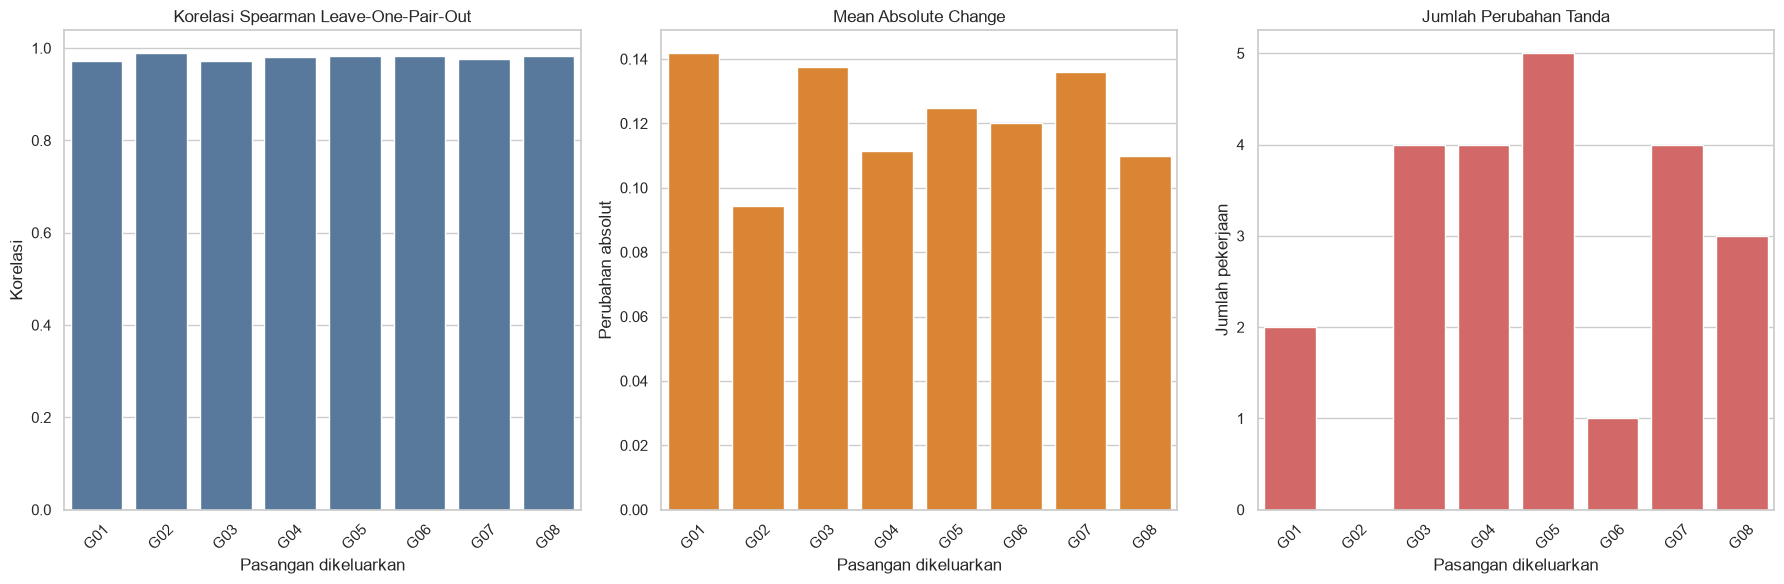

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="spearman_rank_correlation", color="#4C78A8", ax=axes[0])
axes[0].set(title="Korelasi Spearman Leave-One-Pair-Out", xlabel="Pasangan dikeluarkan", ylabel="Korelasi")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="mean_absolute_change", color="#F58518", ax=axes[1])
axes[1].set(title="Mean Absolute Change", xlabel="Pasangan dikeluarkan", ylabel="Perubahan absolut")
axes[1].tick_params(axis="x", rotation=45)
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="sign_change_count", color="#E45756", ax=axes[2])
axes[2].set(title="Jumlah Perubahan Tanda", xlabel="Pasangan dikeluarkan", ylabel="Jumlah pekerjaan")
axes[2].tick_params(axis="x", rotation=45)
fig.tight_layout()
display(fig)
plt.close(fig)

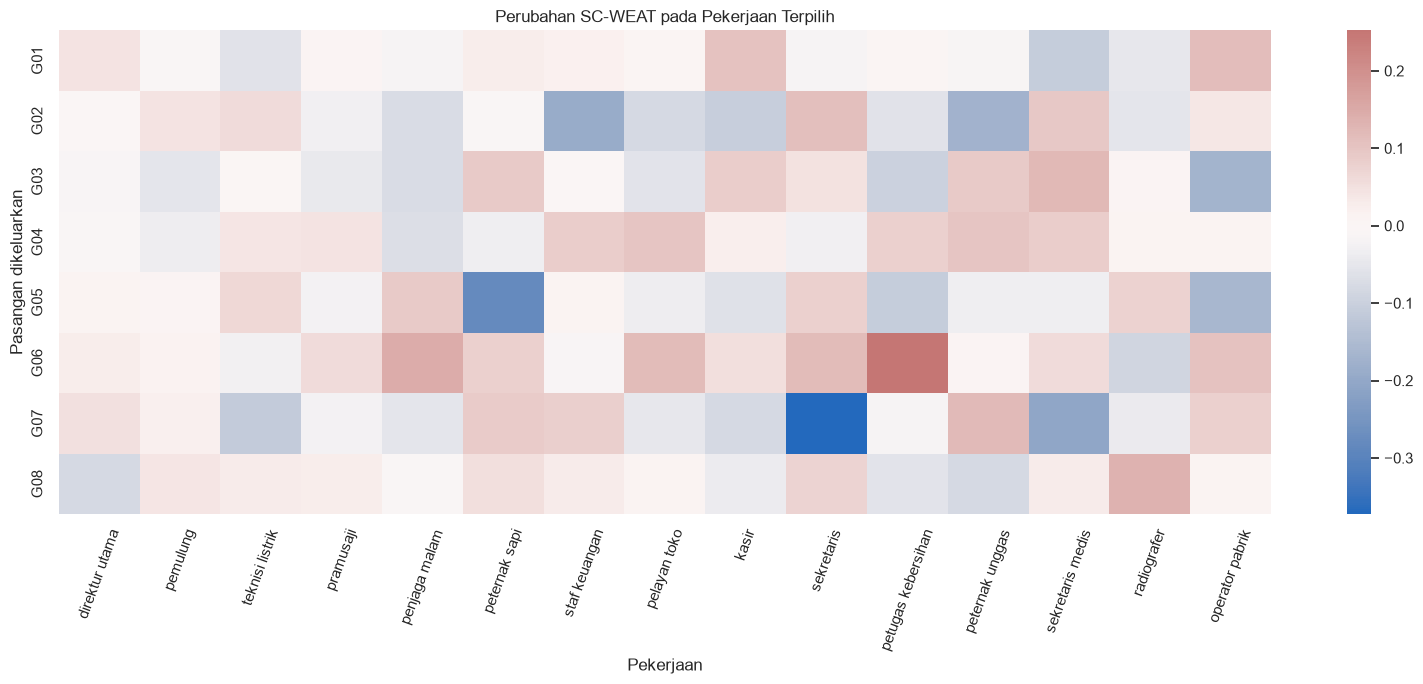

In [28]:
selected_for_sensitivity = scweat_results.reindex(scweat_results["scweat_effect_size"].abs().sort_values(ascending=False).index).head(15)["occupation_name"]
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(sensitivity_effect_matrix[selected_for_sensitivity], cmap="vlag", center=0, ax=ax)
ax.set(title="Perubahan SC-WEAT pada Pekerjaan Terpilih", xlabel="Pekerjaan", ylabel="Pasangan dikeluarkan")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()
display(fig)
plt.close(fig)

## 13. Ringkasan hasil

Angka ringkasan dibentuk dari tabel yang telah dihitung, bukan ditulis manual. Interpretasi hanya berlaku untuk ruang embedding dan konfigurasi analisis ini.

In [29]:
summary_results = pd.DataFrame({
    "metric": ["jumlah pekerjaan", "jumlah kelompok pekerjaan", "rata-rata effect size", "median effect size", "jumlah skor positif", "jumlah skor negatif", "jumlah signifikan FDR", "korelasi sensitivitas minimum", "jumlah maksimum perubahan tanda"],
    "value": [
        len(scweat_results),
        scweat_results["major_group_name"].nunique(),
        scweat_results["scweat_effect_size"].mean(),
        scweat_results["scweat_effect_size"].median(),
        (scweat_results["scweat_effect_size"] > 0).sum(),
        (scweat_results["scweat_effect_size"] < 0).sum(),
        scweat_results["significant_fdr"].sum(),
        sensitivity_results["spearman_rank_correlation"].min(),
        sensitivity_results["sign_change_count"].max(),
    ],
})
display(summary_results.round(4))

,metric,value
0,jumlah pekerjaan,72.0000
1,jumlah kelompok pekerjaan,9.0000
2,rata-rata effect size,-0.2414
3,median effect size,-0.4040
4,jumlah skor positif,26.0000
5,jumlah skor negatif,46.0000
6,jumlah signifikan FDR,15.0000
7,korelasi sensitivitas minimum,0.9716
8,jumlah maksimum perubahan tanda,5.0000


## 14. Menyimpan tabel hasil

Semua tabel ditampilkan di notebook dan disimpan sebagai CSV. Tidak ada visualisasi yang ditulis ke file gambar.

In [30]:
scweat_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_scweat.csv", index=False)
group_summary.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}ringkasan_kelompok.csv", index=False)
permutation_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_permutasi.csv", index=False)
sensitivity_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_sensitivitas.csv", index=False)
output_files = sorted(OUTPUT_DIR.glob(f"{OUTPUT_PREFIX}*.csv"))
display(pd.DataFrame({"output_file": [str(path) for path in output_files]}))

,output_file
0,outputs\demo_v1_hasil_permutasi.csv
1,outputs\demo_v1_hasil_scweat.csv
2,outputs\demo_v1_hasil_sensitivitas.csv
3,outputs\demo_v1_ringkasan_kelompok.csv


## 15. Validasi akhir

Sel terakhir memeriksa struktur data, dimensi vektor, rentang statistik, kelengkapan output, dan kesesuaian jumlah baris hasil.

In [31]:
validation_checks = {
    "occupation_id tidak duplikat": not df_pekerjaan["occupation_id"].duplicated().any(),
    "nama pekerjaan tidak kosong": not df_pekerjaan["occupation_name"].eq("").any(),
    "jumlah atribut gender seimbang": len(male_terms) == len(female_terms),
    "seluruh pasangan gender lengkap": (pair_completeness["gender_group_count"] == 2).all(),
    "seluruh vektor berdimensi 300": occupation_vectors.shape[1] == EMBEDDING_DIM and term_vectors.shape[1] == EMBEDDING_DIM,
    "tidak ada NaN": not np.isnan(occupation_vectors).any() and not np.isnan(term_vectors).any(),
    "tidak ada infinity": not np.isinf(occupation_vectors).any() and not np.isinf(term_vectors).any(),
    "cosine berada pada rentang valid": all_gender_similarity.min() >= -1 - 1e-9 and all_gender_similarity.max() <= 1 + 1e-9,
    "effect size valid": not scweat_results["scweat_effect_size"].isna().any() and np.isfinite(scweat_results["scweat_effect_size"]).all(),
    "p-value berada pada 0 sampai 1": permutation_results["p_value"].between(0, 1).all(),
    "adjusted p-value berada pada 0 sampai 1": permutation_results["adjusted_p_value"].between(0, 1).all(),
    "seluruh output CSV tersedia": all(path.exists() for path in output_files),
    "jumlah baris hasil sesuai pekerjaan": len(scweat_results) == len(df_pekerjaan),
}
validation_table = pd.DataFrame({"check": list(validation_checks), "status": ["PASS" if value else "FAIL" for value in validation_checks.values()]})
display(validation_table)
assert all(validation_checks.values())

,check,status
0,occupation_id tidak duplikat,PASS
1,nama pekerjaan tidak kosong,PASS
2,jumlah atribut gender seimbang,PASS
3,seluruh pasangan gender lengkap,PASS
4,seluruh vektor berdimensi 300,PASS
5,tidak ada NaN,PASS
6,tidak ada infinity,PASS
7,cosine berada pada rentang valid,PASS
8,effect size valid,PASS
9,p-value berada pada 0 sampai 1,PASS


## 16. Kesimpulan dan batas interpretasi

Gunakan tabel dan visualisasi di atas untuk membahas arah asosiasi, pekerjaan ekstrem, perbedaan kelompok, hasil FDR, dan kestabilan sensitivity analysis. SC-WEAT menunjukkan asosiasi relatif dalam ruang embedding pada konfigurasi pengujian, bukan diskriminasi pada aplikasi nyata. Hasil tidak dapat digeneralisasi ke masyarakat Indonesia, distribusi tenaga kerja, KBJI, atau model embedding lain.